<a href="https://colab.research.google.com/github/vijethmd/ML/blob/main/Lab4/1WA23CS041_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# -*- coding: utf-8 -*-
"""LogisticRegression_Binary.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1M8PXdcmPsrQtqyVXpET3sgghAMr_MCg5
"""

# Commented out IPython magic to ensure Python compatibility.
import pandas as pd
from matplotlib import pyplot as plt
# %matplotlib inline
#"%matplotlib inline" will make your plot outputs appear and be stored within the notebook.

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML-Course-6thSem-Feb-2025/Unit-2/insurance_data.csv")
df.head()

plt.scatter(df.age,df.bought_insurance,marker='+',color='red')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,train_size=0.9,random_state=10)
X_train.shape

X_test

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train, y_train)

X_test

y_test

y_predicted = model.predict(X_test)
y_predicted

model.score(X_test,y_test)

model.predict_proba(X_test)

y_predicted = model.predict([[60]])
y_predicted

#model.coef_ indicates value of m in y=m*x + b equation
model.coef_

#model.intercept_ indicates value of b in y=m*x + b equation
model.intercept_

#Lets defined sigmoid function now and do the math with hand
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

def prediction_function(age):
   z = 0.127 * age - 4.973 # 0.12740563 ~ 0.0127 and -4.97335111 ~ -4.97
   y = sigmoid(z)
   return y

age = 35
prediction_function(age)

"""0.37 is less than 0.5 which means person with 35 will not buy the insurance"""

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/ML-Course-6thSem-Feb-2025/Unit-2/insurance_data.csv'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load HR dataset
df = pd.read_csv("HR_comma_sep.csv")

# Show first 5 rows
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [5]:
# Basic statistics
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


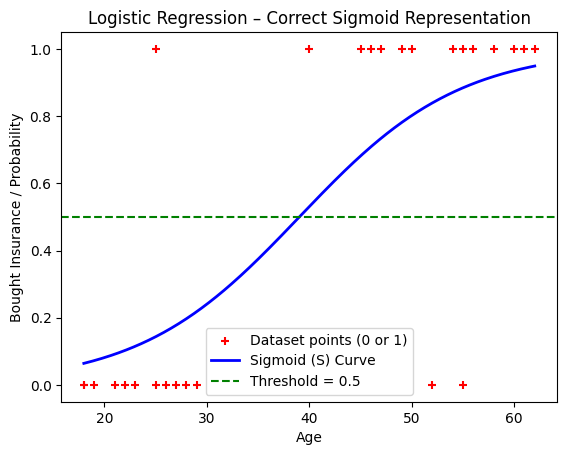

Model Accuracy: 1.0


In [15]:
# -*- coding: utf-8 -*-
"""
Logistic Regression - Binary Classification (Correct Sigmoid Representation)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import math

# Load dataset
df = pd.read_csv("/content/sample_data/insurance_data.csv")

# Prepare data
X = df[['age']]
y = df['bought_insurance']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=10
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------
# CORRECT SIGMOID (S-CURVE) PLOT
# ---------------------------------------------------

# Plot actual dataset points (STRICTLY at 0 and 1)
plt.scatter(df['age'], df['bought_insurance'],
            color='red', marker='+', label='Dataset points (0 or 1)')

# Generate smooth x values
age_range = np.linspace(df['age'].min(), df['age'].max(), 300).reshape(-1, 1)

# Predict probabilities
probabilities = model.predict_proba(age_range)[:, 1]

# Plot sigmoid curve
plt.plot(age_range, probabilities,
         color='blue', linewidth=2, label='Sigmoid (S) Curve')

# Probability threshold
plt.axhline(y=0.5, color='green', linestyle='--', label='Threshold = 0.5')

plt.xlabel("Age")
plt.ylabel("Bought Insurance / Probability")
plt.title("Logistic Regression – Correct Sigmoid Representation")
plt.legend()
plt.show()

# ---------------------------------------------------
# Accuracy
# ---------------------------------------------------
print("Model Accuracy:", model.score(X_test, y_test))

Loaded Iris dataset from sklearn.

Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  species  
0       0        0  
1       0        0  
2       0        0  
3       0        0  
4       0        0  

Accuracy of Multiclass Logistic Regression model: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


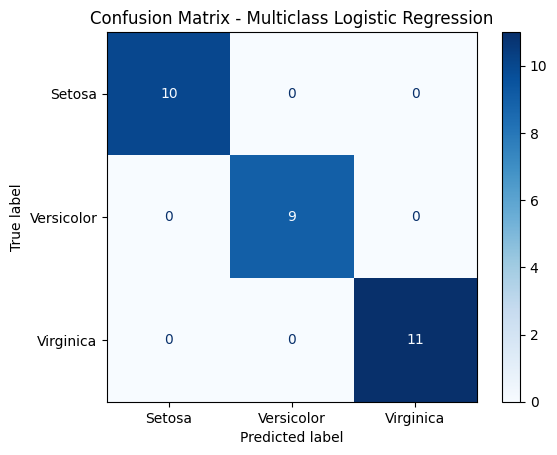

In [11]:
# -*- coding: utf-8 -*-
"""
Logistic Regression - Multiclass Classification (Sample Program)

This program demonstrates multinomial logistic regression
using the Iris dataset.
"""

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------
# Load dataset
# OPTION 1: If iris.csv is uploaded in Colab Files panel
# ---------------------------------------------------
try:
    iris = pd.read_csv("iris.csv")
    print("Loaded iris.csv from local files.")
except:
    # OPTION 2: Load directly from sklearn if csv not found
    from sklearn.datasets import load_iris
    iris_data = load_iris(as_frame=True)
    iris = iris_data.frame
    iris['species'] = iris_data.target
    print("Loaded Iris dataset from sklearn.")

# Display first 5 rows
print("\nDataset Preview:")
print(iris.head())

# ---------------------------------------------------
# Separate features and target
# ---------------------------------------------------
X = iris.drop('species', axis=1)
y = iris['species']

# ---------------------------------------------------
# Train-test split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------
# Initialize Multiclass Logistic Regression model
# ---------------------------------------------------
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=200
)

# ---------------------------------------------------
# Train the model
# ---------------------------------------------------
model.fit(X_train, y_train)

# ---------------------------------------------------
# Make predictions
# ---------------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------------
# Model accuracy
# ---------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of Multiclass Logistic Regression model: {accuracy:.2f}")

# ---------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Setosa", "Versicolor", "Virginica"]
)

cm_display.plot(cmap="Blues")
plt.title("Confusion Matrix - Multiclass Logistic Regression")
plt.show()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load HR dataset
df = pd.read_csv("HR_comma_sep.csv")

# Preview dataset
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [18]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [19]:
# Convert salary to dummy variables
salary_dummies = pd.get_dummies(df['salary'], drop_first=True)

# Convert department (sales) to dummy variables
dept_dummies = pd.get_dummies(df['sales'], drop_first=True)

# Combine with original dataframe
df_final = pd.concat([
    df.drop(['salary', 'sales'], axis=1),
    salary_dummies,
    dept_dummies
], axis=1)

df_final.head()

KeyError: 'sales'

In [20]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [21]:
# Convert salary to dummy variables
salary_dummies = pd.get_dummies(df['salary'], drop_first=True)

# Convert Department to dummy variables (CORRECT column name)
dept_dummies = pd.get_dummies(df['Department'], drop_first=True)

# Combine all features into final dataframe
df_final = pd.concat([
    df.drop(['salary', 'Department'], axis=1),
    salary_dummies,
    dept_dummies
], axis=1)

# Preview final dataset
df_final.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,low,medium,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical
0,0.38,0.53,2,157,3,0,1,0,True,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,False,True,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,False,True,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,True,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,True,False,False,False,False,False,False,False,True,False,False


In [22]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_final.drop('left', axis=1)
y = df_final['left']

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((11999, 18), (3000, 18))

In [23]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)

y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Logistic Regression model:", accuracy)

Accuracy of Logistic Regression model: 0.7823333333333333


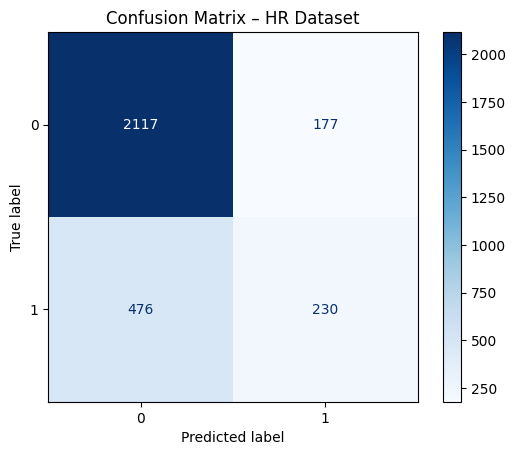

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – HR Dataset")
plt.show()

In [27]:
import pandas as pd

# Load datasets
zoo = pd.read_csv("/content/zoo-data.csv")
class_type = pd.read_csv("/content/zoo-class-type.csv")

# Preview
zoo.head(), class_type.head()

(  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
 0    aardvark     1         0     0     1         0        0         1   
 1    antelope     1         0     0     1         0        0         0   
 2        bass     0         0     1     0         0        1         1   
 3        bear     1         0     0     1         0        0         1   
 4        boar     1         0     0     1         0        0         1   
 
    toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
 0        1         1         1         0     0     4     0         0        1   
 1        1         1         1         0     0     4     1         0        1   
 2        1         1         0         0     1     0     1         0        0   
 3        1         1         1         0     0     4     0         0        1   
 4        1         1         1         0     0     4     1         0        1   
 
    class_type  
 0           1  
 1           1  
 2 

In [28]:
# Check columns
zoo.columns

Index(['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type'],
      dtype='object')

In [31]:
# Features (drop animal name and target)
X = zoo.drop(['animal_name', 'class_type'], axis=1)

# Target
y = zoo['class_type']

X.head(), y.head()

(   hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  backbone  \
 0     1         0     0     1         0        0         1        1         1   
 1     1         0     0     1         0        0         0        1         1   
 2     0         0     1     0         0        1         1        1         1   
 3     1         0     0     1         0        0         1        1         1   
 4     1         0     0     1         0        0         1        1         1   
 
    breathes  venomous  fins  legs  tail  domestic  catsize  
 0         1         0     0     4     0         0        1  
 1         1         0     0     4     1         0        1  
 2         0         0     1     0     1         0        0  
 3         1         0     0     4     0         0        1  
 4         1         0     0     4     1         0        1  ,
 0    1
 1    1
 2    4
 3    1
 4    1
 Name: class_type, dtype: int64)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [36]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Zoo Dataset Accuracy:", accuracy_score(y_test, y_pred))

Zoo Dataset Accuracy: 0.9523809523809523


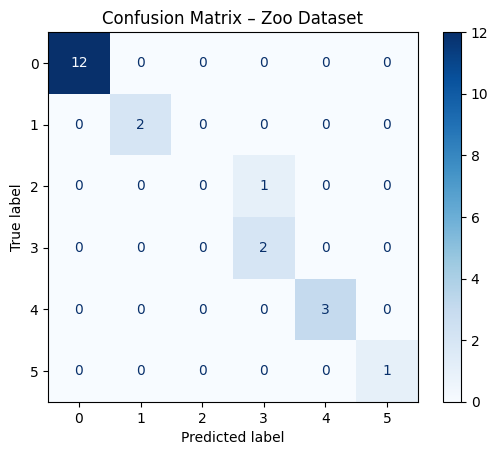

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Zoo Dataset")
plt.show()

In [30]:
zoo.columns

Index(['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type'],
      dtype='object')